# Cross-species integration via orthologs

Single-cell datasets from **different species** live in different gene-symbol
spaces, so they cannot be integrated directly. omicverse bridges them with
**one-to-one orthologs** from Ensembl BioMart, then reuses its existing
integration backends to align the datasets *across species*
([issue #856](https://github.com/omicverse/omicverse/issues/856)).

Everything is in `ov.single`:

1. `get_orthologs(source, target)` — homologous-gene table from Ensembl BioMart.
2. `map_var_to_orthologs(adata, source, target)` — transfer a dataset onto the
   other species' gene symbols.
3. `cross_species_integrate([...], [...])` — align to a reference species, keep
   the shared orthologs, and integrate.

We use the **SATURN** frog + zebrafish embryogenesis pair — two *distant*
vertebrates (~430 Myr diverged). At that distance a linear correction (Harmony)
is not enough, so we integrate with **scVI**. As we'll see, one-to-one orthologs
carry enough signal to align the major **germ layers** across species, but *fine*
cell-type homology at this distance is where protein-embedding methods (SATURN)
go further — we quantify exactly that below.

In [1]:
import omicverse as ov
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the SATURN frog + zebrafish data

`ov.datasets.saturn_frog_zebrafish()` returns two AnnData objects with **raw
counts**, species-native gene symbols, and SATURN's harmonized `cell_type` /
`germ_layer` labels — small sparse conversions of SATURN's official sources
(Briggs et al. 2018 *Xenopus*; Wagner et al. 2018 zebrafish).

In [2]:
frog, zebrafish = ov.datasets.saturn_frog_zebrafish()
shared = sorted(set(frog.obs['cell_type']) & set(zebrafish.obs['cell_type']))
print('frog     :', frog.shape)
print('zebrafish:', zebrafish.shape)
print(f'shared harmonized cell types: {len(shared)}')

🔍 Downloading data to ./data/frog_saturn.h5ad
⚠️ File ./data/frog_saturn.h5ad already exists
🔍 Downloading data to ./data/zebrafish_saturn.h5ad
⚠️ File ./data/zebrafish_saturn.h5ad already exists
frog     : (4837, 22382)
zebrafish: (5983, 16950)
shared harmonized cell types: 28


## 2. Homologous-gene transfer (Ensembl BioMart)

In [3]:
ortho = ov.single.get_orthologs('zebrafish', 'frog')   # danio -> xenopus
print('one-to-one zebrafish->frog orthologs:', len(ortho))
ortho.head()

one-to-one zebrafish->frog orthologs: 9253


,source_symbol,target_symbol,orthology_type
0,tmem177,tmem177,ortholog_one2one
1,ostc,ostc,ortholog_one2one
2,rab9b,rab9b,ortholog_one2one
3,slc39a9,slc39a9,ortholog_one2one
4,gpkow,gpkow,ortholog_one2one


## 3. Cross-species integration with scVI

`cross_species_integrate` maps both datasets onto the reference species'
one-to-one orthologs, keeps the shared genes, adds a `species` batch label, and
runs the backend. For these distant species we use **scVI** (raw counts, NB
likelihood).

In [4]:
adata = ov.single.cross_species_integrate(
    [zebrafish, frog], ['zebrafish', 'frog'],
    ref_species='zebrafish', method='scVI',
    n_top_genes=2000, n_pcs=30)
adata.uns['cross_species']

...Begin using scVI to correct batch effect


INFO: GPU available: True (cuda), used: True


INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True


INFO: TPU available: False, using: 0 TPU cores


INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


...

Training:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.


INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.



╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 181.9187s                                               │
│  Shape:    10,820 x 2,000 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ _scvi_batch (int)                                    │
│           │ ✚ _scvi_labels (int)                                   │
│                                                                    │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ _scvi_manager_uuid                                   │
│           │ ✚ _scvi_uuid                                           │
│                                                                    │
│  ● 

{'ref_species': 'zebrafish',
 'species': ['zebrafish', 'frog'],
 'n_common_orthologs': 5603,
 'orthology_type': 'one2one',
 'method': 'scVI'}

## 4. Visualise

Embed on the scVI representation and colour by species and by germ layer.

INFO:omicverse.pp._neighbors:computing neighbors


🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 15
   Method: umap
   Metric: euclidean
   Representation: X_scVI
   🔍 Computing neighbor distances...


   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 10,820 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 23.741s                                                 │
│  Shape:    10,820 x 2,000 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivi


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 10,820 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 1.8922s                                                 │
│  Shape:    10,820 x 2,000 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414425), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 10820x2)                              │
│                

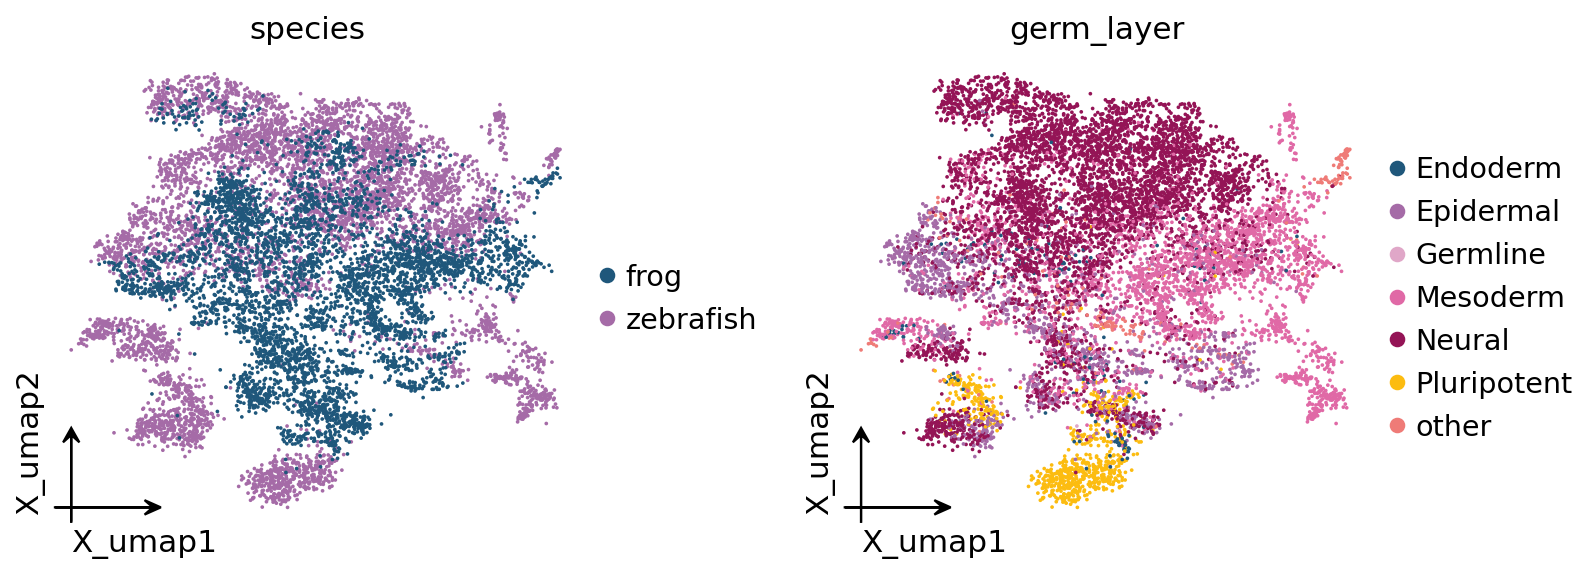

In [5]:
ov.pp.neighbors(adata, use_rep='X_scVI', n_neighbors=15)
ov.pp.umap(adata)
ov.pl.embedding(adata, basis='X_umap', color=['species', 'germ_layer'],
                frameon='small', wspace=0.5)

## 5. Evaluate — cell-type consistency, not just species mixing

A cluster containing both species is **not** proof of good integration: an
over-aggressive method can blend everything and still look "mixed". The honest
test is whether **homologous cell types align across species**. We measure it as
cross-species **label transfer**: train a kNN classifier on *zebrafish* labels in
the embedding, predict the *frog* cells, and compare to their true labels —
before (raw ortholog PCA) vs after scVI, at germ-layer and fine cell-type
resolution.

In [6]:
def xspecies_transfer(rep, label):
    m = adata.obsm[rep]
    sp = adata.obs['species'].values
    y = adata.obs[label].astype(str).values
    shared = (set(y[sp == 'zebrafish']) & set(y[sp == 'frog'])) - {'other'}
    tr = (sp == 'zebrafish') & np.isin(y, list(shared))
    te = (sp == 'frog') & np.isin(y, list(shared))
    knn = KNeighborsClassifier(n_neighbors=15).fit(m[tr], y[tr])
    return (knn.predict(m[te]) == y[te]).mean(), len(shared)

for label in ['germ_layer', 'cell_type']:
    a_pre, n = xspecies_transfer('X_pca', label)
    a_post, _ = xspecies_transfer('X_scVI', label)
    print(f'{label:11s} ({n:2d} classes, chance~{1/n:.2f}):  '
          f'before={a_pre:.2f}  after scVI={a_post:.2f}')

germ_layer  ( 6 classes, chance~0.17):  before=0.54  after scVI=0.57


cell_type   (28 classes, chance~0.04):  before=0.22  after scVI=0.23


## Beyond one-to-one orthologs: SAMap & SATURN

The ortholog route above only uses **one-to-one** orthologs, which lose
resolution at large evolutionary distances. The **same**
`cross_species_integrate` / `CrossSpecies` entry point reaches two homology-aware
backends (vendored under `omicverse.external`) — just change `method=`. Both need
protein data (BLAST proteomes / ESM embeddings), so they are heavier; we run them
in full below.

First, a `cell_type → germ_layer` lookup (from the loaded data) to colour the
results consistently:

In [7]:
c2g = dict(zip(
    pd.concat([zebrafish.obs['cell_type'], frog.obs['cell_type']]).astype(str),
    pd.concat([zebrafish.obs['germ_layer'], frog.obs['germ_layer']]).astype(str)))

### SAMap — reciprocal-BLAST homology graph

`build_blast_maps` defaults to **DIAMOND** (~40-50× faster than NCBI `blastp` —
reciprocal frog↔zebrafish maps in ~1 min, both directions concurrent). Then
`method='samap'` builds the gene-homology graph and runs the Self-Assembling
Manifold.

In [8]:
# download the two Ensembl peptide proteomes (SAMap's BLAST inputs)
zf_fa = ov.datasets.download_data('https://github.com/omicverse/omicverse-tutorials/releases/download/data-saturn-fz/Danio_rerio.GRCz11.pep.all.fa.gz',
                                  file_path='zf.pep.fa.gz', dir='data')
fr_fa = ov.datasets.download_data('https://github.com/omicverse/omicverse-tutorials/releases/download/data-saturn-fz/Xenopus_tropicalis.UCB_Xtro_10.0.pep.all.fa.gz',
                                  file_path='fr.pep.fa.gz', dir='data')

from omicverse.external.samap._run import build_blast_maps
build_blast_maps({'zf': zf_fa, 'fr': fr_fa}, out_dir='data/maps',
                 engine='diamond', threads=8)

adata_samap = ov.single.cross_species_integrate(
    [zebrafish, frog], ['zebrafish', 'frog'], method='samap', ids=['zf', 'fr'],
    proteomes={'zf': zf_fa, 'fr': fr_fa}, blast_maps='data/maps')

🔍 Downloading data to data/zf.pep.fa.gz


Downloading: |          | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/13.5M [00:00<?, ?B/s]

Downloading:  43%|████▎     | 5.76M/13.5M [00:00<00:00, 57.3MB/s]

Downloading:  78%|███████▊  | 10.5M/13.5M [00:00<00:00, 28.0MB/s]

...

Rescaling edge weights by expression correlations.


Concatenating SAM objects...


Iteration 3 complete.
Alignment scores:
          fr        zf
fr  0.000000  0.690466
zf  0.686793  0.000000


Running UMAP on the stitched manifolds.


Elapsed time: 1.3494000991185506 minutes.


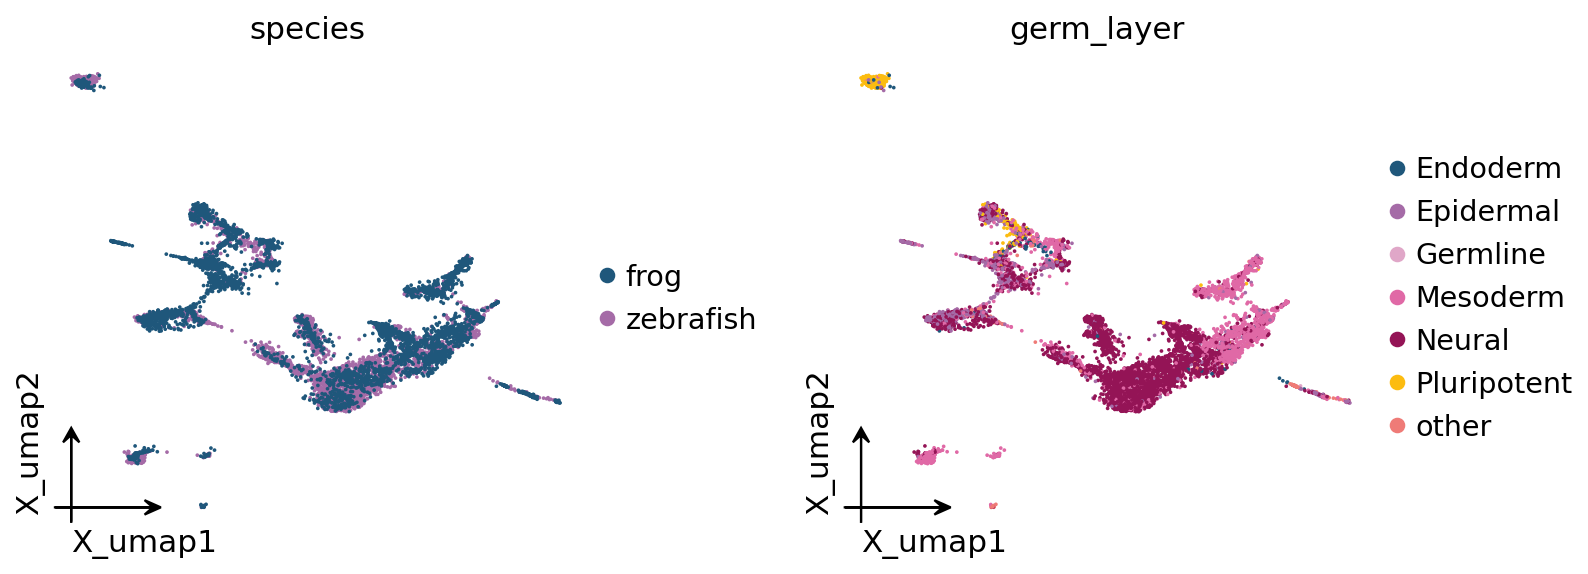

In [9]:
sp = adata_samap.obs['species'].astype(str)
adata_samap.obs['species'] = np.where(sp == 'zf', 'zebrafish', 'frog')
ct = np.where(sp == 'zf', adata_samap.obs.get('zf_cell_type').astype(str),
                          adata_samap.obs.get('fr_cell_type').astype(str))
adata_samap.obs['cell_type'] = ct
adata_samap.obs['germ_layer'] = [c2g.get(x, 'other') for x in ct]
ov.pl.embedding(adata_samap, basis='X_umap', color=['species', 'germ_layer'],
                frameon='small', wspace=0.5)

### SATURN — ESM2 protein-embedding macrogenes

SATURN needs an **ESM2 protein embedding** per species (a `torch` dict
`{gene_symbol: vector}`; generating it over each proteome is the expensive step,
so we download precomputed ones). We use the `CrossSpecies` **class** so the
trained model comes back and the whole run can be persisted with `ov.io.save`.

In [10]:
zf_emb = ov.datasets.download_data('https://github.com/omicverse/omicverse-tutorials/releases/download/data-saturn-fz/zebrafish_esm.pt',
                                   file_path='zebrafish_esm.pt', dir='data')
fr_emb = ov.datasets.download_data('https://github.com/omicverse/omicverse-tutorials/releases/download/data-saturn-fz/frog_esm.pt',
                                   file_path='frog_esm.pt', dir='data')

cs = ov.single.CrossSpecies(
    [zebrafish, frog], ['zebrafish', 'frog'], method='saturn',
    embedding_paths={'zebrafish': zf_emb, 'frog': fr_emb},
    in_label_col='cell_type', n_macrogenes=2000, epochs=(50, 50),
    device='cuda', work_dir='data/saturn_work').fit()

ov.io.save(cs, 'data/saturn_run.pkl')     # persist run + trained model (cs.model)
adata_saturn = cs.adata

🔍 Downloading data to data/zebrafish_esm.pt


Downloading: |          | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/67.0M [00:00<?, ?B/s]

Downloading:   8%|▊         | 5.38M/67.0M [00:00<00:01, 53.7MB/s]

Downloading:  13%|█▎        | 8.54M/67.0M [00:00<00:01, 33.1MB/s]

...

 55%|█████▍    | 6/11 [00:00<00:00, 26.65it/s]

 82%|████████▏ | 9/11 [00:00<00:00, 26.60it/s]

100%|██████████| 11/11 [00:00<00:00, 27.66it/s]

💾 Save Operation:
   Target path: data/saturn_run.pkl
   Object type: CrossSpecies
   Using: pickle


   ✅ Successfully saved!
────────────────────────────────────────────────────────────


INFO:omicverse.pp._neighbors:computing neighbors


🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 15
   Method: umap
   Metric: euclidean
   Representation: X_saturn
   🔍 Computing neighbor distances...


   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity
   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 10,820 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 2.8541s                                                 │
│  Shape:    10,820 x 256 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ neighbors     


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 10,820 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 17.3013s                                                │
│  Shape:    10,820 x 256 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414425), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 10820x2)                              │
│                

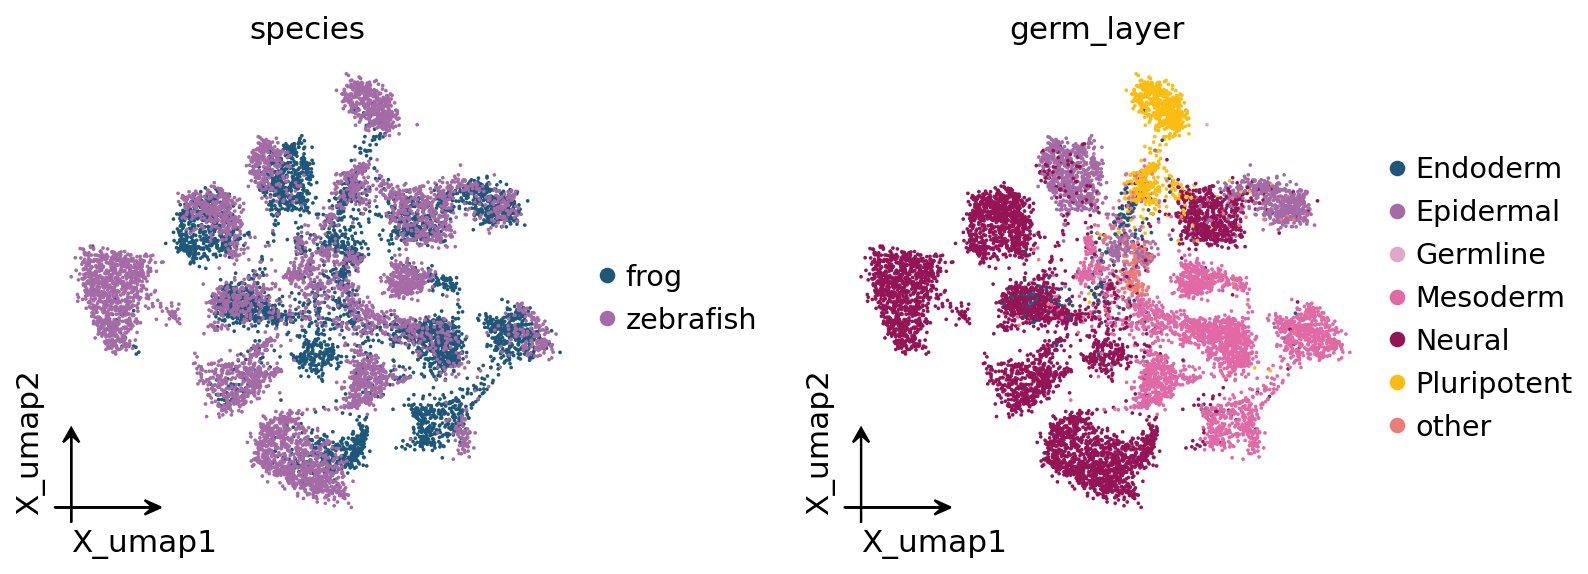

In [11]:
adata_saturn.obs['cell_type'] = adata_saturn.obs['labels2'].astype(str)
adata_saturn.obs['germ_layer'] = [c2g.get(x, 'other') for x in adata_saturn.obs['cell_type']]
ov.pp.neighbors(adata_saturn, use_rep='X_saturn', n_neighbors=15)
ov.pp.umap(adata_saturn)
ov.pl.embedding(adata_saturn, basis='X_umap', color=['species', 'germ_layer'],
                frameon='small', wspace=0.5)

### CAMEX — heterogeneous GNN over a many-to-many homology graph

CAMEX doesn't need protein data: it builds the **many-to-many** homolog graph
(from BioMart, automatically) and runs a graph neural network. Unlike SAMap /
SATURN it natively integrates **>2 species** in one call and does annotation
transfer. Here it runs in-process (GPU); with `method='camex'` the many-to-many
homology is fetched for you.

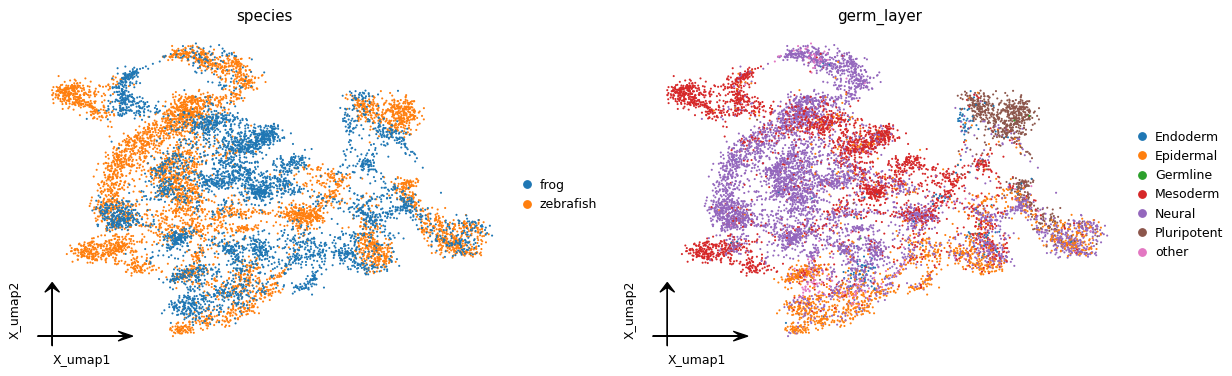

In [ ]:
adata_camex = ov.single.cross_species_integrate(
    [zebrafish, frog], ['zebrafish', 'frog'], method='camex',
    epoch_integration=100, device='cuda')     # >2 species: just pass more adatas
ov.pp.neighbors(adata_camex, use_rep='X_CAMEX_Integration', n_neighbors=15)
ov.pp.umap(adata_camex)
ov.pl.embedding(adata_camex, basis='X_umap', color=['species', 'germ_layer'],
                frameon='small', wspace=0.5)

### Which method, and how well do they align cell types?

Species *mixing* alone is misleading, so we score **cross-species cell-type label
transfer** (train a kNN on zebrafish labels in each method's embedding, predict
the frog cells) at germ-layer and fine cell-type resolution.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

def xtransfer(a, rep, label):
    m = a.obsm[rep]; sp = a.obs['species'].astype(str).values
    y = a.obs[label].astype(str).values
    shared = (set(y[sp=='zebrafish']) & set(y[sp=='frog'])) - {'other','nan','None'}
    tr = (sp=='zebrafish') & np.isin(y, list(shared))
    te = (sp=='frog') & np.isin(y, list(shared))
    knn = KNeighborsClassifier(n_neighbors=15).fit(m[tr], y[tr])
    return (knn.predict(m[te]) == y[te]).mean()

print(f"{'method':16s} germ-layer  cell-type")
for name, a, rep in [('orthologs+scVI', adata, 'X_scVI'),
                     ('SAMap', adata_samap, 'X_umap'),
                     ('SATURN', adata_saturn, 'X_saturn'),
                     ('CAMEX', adata_camex, 'X_CAMEX_Integration')]:
    g = xtransfer(a, rep, 'germ_layer'); ct = xtransfer(a, rep, 'cell_type')
    print(f"{name:16s} {g:.2f}        {ct:.2f}")

method           germ-layer  cell-type
orthologs+scVI   0.57        0.23
SAMap            0.68        0.41
SATURN           0.86        0.62
CAMEX            0.55        0.24


## Summary

One entry point, four methods via `method=` (`CrossSpecies` / `cross_species_integrate`):

| `method=` | approach | homology signal |
|---|---|---|
| `'scVI'` / `'harmony'` / … | one-to-one orthologs + `batch_correction` | BioMart |
| `'samap'` | **SAMap** reciprocal-BLAST homology graph | proteomes / BLAST |
| `'saturn'` | **SATURN** ESM2 macrogenes | ESM2 embeddings |
| `'camex'` | **CAMEX** heterogeneous GNN (multi-species, >2) | many-to-many homology (BioMart) |

The deeper the homology signal a method uses (one-to-one orthologs → BLAST graph
→ protein embeddings), the better fine cell types align across distant species —
at increasing input/compute cost (see the table above).

- `ov.single.cross_species_integrate(..., method=...)` — one call, returns the AnnData.
- `ov.single.CrossSpecies(...).fit()` — the class; keeps `.adata` + `.model`, and
  `ov.io.save` persists the run.
- `ov.tl.cross_species_align` — the ortholog preprocessing on its own.